# Negotiation Arena: Human and LLM Negotiation Dynamics

This project investigates how LLM agents behave in negotiation settings and compares their behavior with human negotiation patterns from the Negochat corpus.

The main goal is not to build a perfect negotiation agent, but to analyze how LLMs generate negotiation moves, how they reach or fail to reach closure, and how their outcomes depend on evaluation rules.

## Research Question

How do LLM agents behave in negotiation settings compared with human negotiators, and how sensitive are their outcomes to prompting, utility constraints, and termination rules?

## Experimental Design

The project contains three main components:

1. **Human baseline analysis**  
   The Negochat corpus is used to analyze human negotiation behavior through dialogue acts, issues, turn lengths, and inferred outcomes.

2. **Human-seeded LLM continuation experiment**  
   LLM agents continue negotiations starting from the first substantive negotiation act of real Negochat dialogues. This tests whether LLMs can continue human-like negotiation contexts.

3. **Utility-based multi-issue LLM experiment**  
   LLM agents negotiate a full job contract package across multiple issues. Each proposed package is evaluated using private utility tables for Candidate and Employer. This allows us to distinguish between explicit linguistic acceptance and strategically valid agreement.

During development, several termination rules were tested. These methodological iterations are discussed as part of the project because they reveal an important challenge in LLM negotiation environments: defining what counts as agreement.

In [125]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_or_create_human_data
from src.visualization import plot_transition_heatmap
from src.metrics import  infer_human_outcome, infer_human_outcome_refined, compute_transition_matrix

# DATA LOADING

In [126]:
human_df = load_or_create_human_data(
    raw_path="../data/raw/negochat",
    processed_path="../data/processed/human_negotiations.csv"
)

seeded_turns = pd.read_csv("../results/human_seeded_llm_turns_sample.csv")
seeded_outcomes = pd.read_csv("../results/human_seeded_llm_outcomes_sample.csv")

utility_turns = pd.read_csv("../results/utility_llm_turns_llama3.csv")
utility_outcomes = pd.read_csv("../results/utility_llm_outcomes_llama3.csv")

print("Human data:", human_df.shape)
print("Human-seeded LLM turns:", seeded_turns.shape)
print("Human-seeded LLM outcomes:", seeded_outcomes.shape)
print("Utility LLM turns:", utility_turns.shape)
print("Utility LLM outcomes:", utility_outcomes.shape)

Human data: (4993, 8)
Human-seeded LLM turns: (360, 9)
Human-seeded LLM outcomes: (20, 8)
Utility LLM turns: (145, 15)
Utility LLM outcomes: (27, 7)


## HUMAN BASELINE : NEGOCHAT

In [127]:
human_act_counts = human_df["act"].value_counts()
human_act_counts

act
Offer     2996
Reject     790
Accept     547
Other      394
Greet      135
Query      113
Quit        18
Name: count, dtype: int64

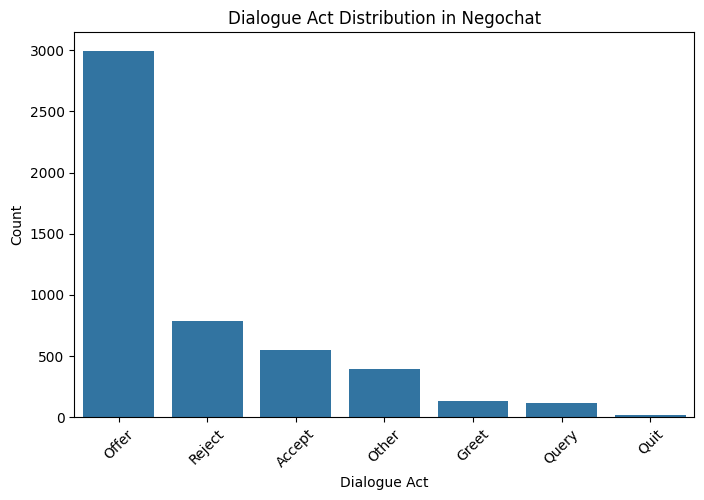

In [128]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=human_df,
    x="act",
    order=human_df["act"].value_counts().index
)
plt.title("Dialogue Act Distribution in Negochat")
plt.xlabel("Dialogue Act")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Dialogue Act Transitions


In [169]:
human_transition_matrix = compute_transition_matrix(
    human_df,
    act_col="act"
)

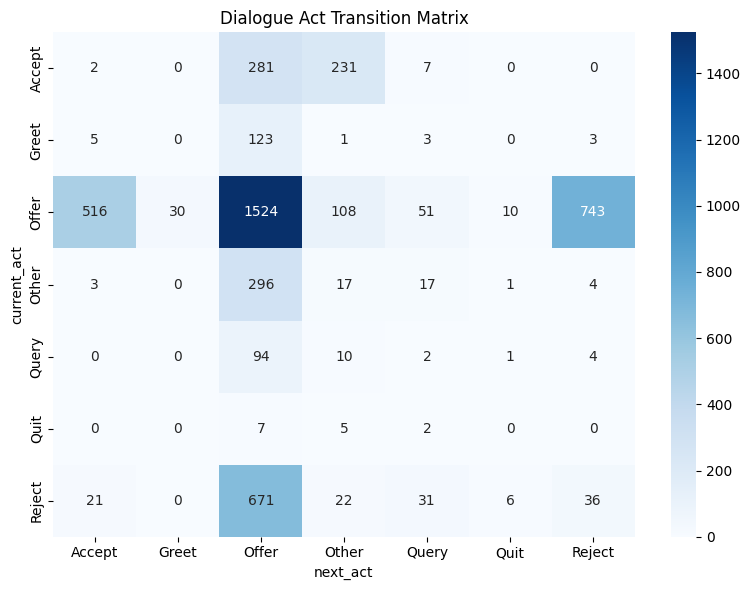

In [170]:
plot_transition_heatmap(human_transition_matrix)

In [171]:
human_issue_counts = human_df["issue"].value_counts()

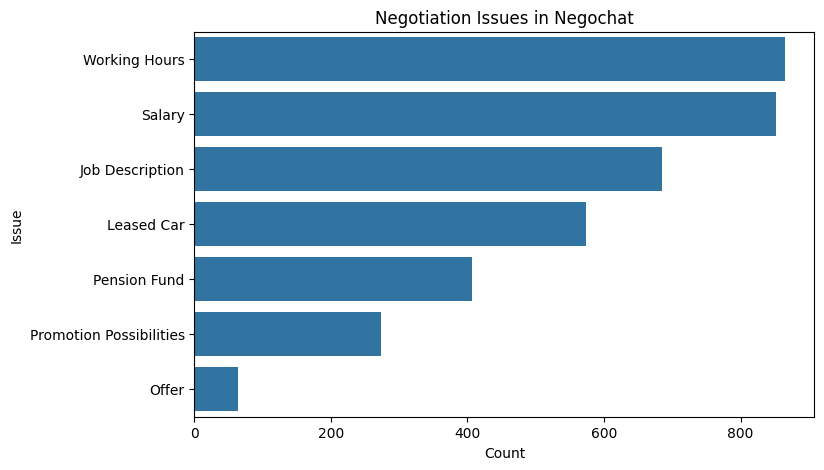

In [172]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=human_df,
    y="issue",
    order=human_df["issue"].value_counts().index
)
plt.title("Negotiation Issues in Negochat")
plt.xlabel("Count")
plt.ylabel("Issue")
plt.show()

## HUMAN DATASET OUTCOMES: simple heuristic vs refined heuristic 

In [133]:
human_outcomes = (
    human_df
    .groupby("dialogue_id")
    .apply(lambda g: pd.Series({
        "outcome": infer_human_outcome(g),
        "n_turns": g["turn_id"].nunique()
    }))
    .reset_index()
)

human_outcomes["outcome"].value_counts()

outcome
Agreement     103
Failure         1
Unresolved      1
Name: count, dtype: int64

In [134]:
human_refined_outcomes = (
    human_df
    .groupby("dialogue_id")
    .apply(lambda g: pd.Series({
        "refined_outcome": infer_human_outcome_refined(g, final_window=3),
        "n_turns": g["turn_id"].nunique()
    }))
    .reset_index()
)

human_refined_outcomes["refined_outcome"].value_counts()

refined_outcome
FinalAgreement                 78
PartialOrIntermediateAccept    25
Failure                         1
Unresolved                      1
Name: count, dtype: int64

# Human-seeded LLM experiments 

In [167]:
seeded_outcomes["outcome"].value_counts()

outcome
Impasse      11
Agreement     9
Name: count, dtype: int64

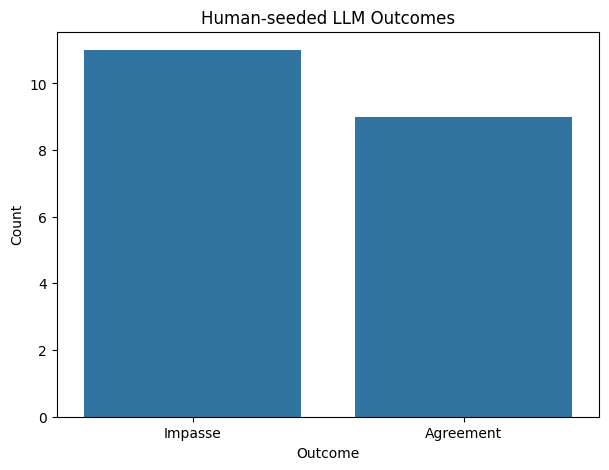

In [140]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=seeded_outcomes,
    x="outcome",
    order=seeded_outcomes["outcome"].value_counts().index
)
plt.title("Human-seeded LLM Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

The human-seeded experiment provides a more direct comparison between human and LLM negotiation trajectories. Each LLM simulation starts from the first substantive negotiation act of a real Negochat dialogue.

The results show that LLM agents can continue negotiations in locally plausible ways, but they often end in Impasse rather than reaching the same type of agreement observed in the original human dialogues.

In [143]:
human_act_percentages = (
    human_df["act"]
    .value_counts(normalize=True)
    .mul(100)
)

llm_seeded_act_percentages = (
    seeded_turns["act"]
    .value_counts(normalize=True)
    .mul(100)
)

act_comparison = pd.DataFrame({
    "Human Negochat": human_act_percentages,
    "Human-seeded LLM": llm_seeded_act_percentages
}).fillna(0)

act_order = ["Offer", "Accept", "Reject", "Query", "Greet", "Quit", "Other"]

act_comparison = act_comparison.reindex(act_order).fillna(0)

act_comparison

,Human Negochat,Human-seeded LLM
act,,
Offer,60.004006,61.363636
Accept,10.955337,2.556818
Reject,15.822151,1.704545
Query,2.263168,32.954545
Greet,2.703785,0.000000
Quit,0.360505,0.000000
Other,7.891047,1.420455


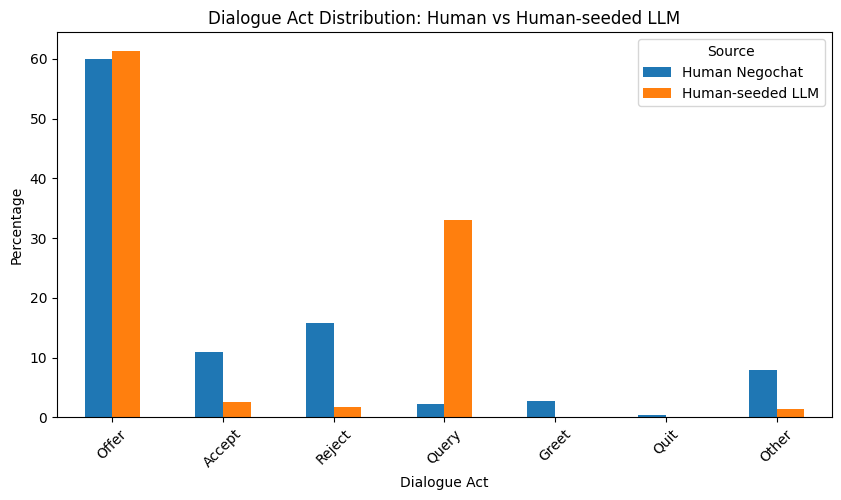

In [162]:
act_comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Dialogue Act Distribution: Human vs Human-seeded LLM")
plt.ylabel("Percentage")
plt.xlabel("Dialogue Act")
plt.xticks(rotation=45)
plt.legend(title="Source")
plt.show()

## Paired Comparison: Human vs Human-seeded 

In [164]:
sample_ids = seeded_outcomes["dialogue_id"].astype(str).unique()

human_sample_outcomes = human_outcomes[
    human_outcomes["dialogue_id"].astype(str).isin(sample_ids)
].copy()

human_sample_outcomes["dialogue_id"] = human_sample_outcomes["dialogue_id"].astype(str)

seeded_outcomes_compare = seeded_outcomes.copy()
seeded_outcomes_compare["dialogue_id"] = seeded_outcomes_compare["dialogue_id"].astype(str)

paired_comparison = human_sample_outcomes.merge(
    seeded_outcomes_compare,
    on="dialogue_id",
    suffixes=("_human", "_llm")
)

paired_comparison[[
    "dialogue_id",
    "outcome_human",
    "outcome_llm",
    "n_turns_human",
    "n_turns_llm"
]]

,dialogue_id,outcome_human,outcome_llm,n_turns_human,n_turns_llm
0,2,Agreement,Agreement,16,13
1,3,Agreement,Agreement,32,17
2,9,Agreement,Impasse,23,21
3,14,Agreement,Agreement,27,17
4,16,Agreement,Impasse,14,15
5,17,Agreement,Impasse,48,21
6,29,Agreement,Impasse,35,21
7,30,Agreement,Impasse,37,21
8,32,Agreement,Agreement,27,21
9,36,Agreement,Impasse,18,19


The paired comparison shows that the original human dialogues usually reach Agreement, while LLM continuations often produce Impasse. This suggests that LLM agents can generate plausible local negotiation turns, but they are less reliable in managing global negotiation closure.

# Human vs LLM Dialogue Acts

The dialogue act comparison shows that LLM agents rely heavily on offers and questions, while human negotiators display a broader distribution of acts, including more explicit rejections and acceptances. This supports the idea that LLM agents can imitate negotiation language locally, but their dialogue dynamics are less diverse and less decisive than human negotiations.

## Evaluation Rule Sensitivity: Explicit Acceptance vs Compatibility

The controlled LLM experiment was used to test how different evaluation rules affect the observed negotiation outcome.

During development, two versions of the same controlled Llama3 experiment were tested.

In the first version, a negotiation was classified as Agreement only if the model explicitly produced `DECISION: accept`. This is a strict evaluation rule because it requires explicit conversational closure.

In the second version, a compatibility-based evaluator was used. Under this rule, a negotiation was classified as Agreement when the environment detected an offer satisfying both agents’ hard constraints. This is a more permissive rule because it counts mutually compatible offers as agreements even when the model does not explicitly close the dialogue.

Comparing these two versions shows that LLM negotiation outcomes are highly sensitive to the evaluation and termination rules used by the environment.

In [147]:
explicit_outcomes = pd.read_csv("../results/controlled_llama3_explicit_outcomes.csv")
explicit_turns = pd.read_csv("../results/controlled_llama3_explicit_turns.csv")

compat_outcomes = pd.read_csv("../results/controlled_llama3_compatibility_outcomes.csv")
compat_turns = pd.read_csv("../results/controlled_llama3_compatibility_turns.csv")

print("Explicit outcomes:", explicit_outcomes.shape)
print("Explicit turns:", explicit_turns.shape)
print("Compatibility outcomes:", compat_outcomes.shape)
print("Compatibility turns:", compat_turns.shape)

Explicit outcomes: (27, 5)
Explicit turns: (432, 9)
Compatibility outcomes: (27, 5)
Compatibility turns: (423, 9)


In [148]:
explicit_outcomes["outcome"].value_counts()

outcome
Timeout    27
Name: count, dtype: int64

In [149]:
compat_outcomes["outcome"].value_counts()

outcome
Agreement    25
Impasse       2
Name: count, dtype: int64

In [150]:
evaluation_rule_summary = pd.DataFrame({
    "evaluation_rule": [
        "Explicit acceptance only",
        "Compatibility-based evaluator"
    ],
    "n_runs": [
        len(explicit_outcomes),
        len(compat_outcomes)
    ],
    "main_outcome": [
        explicit_outcomes["outcome"].value_counts().idxmax(),
        compat_outcomes["outcome"].value_counts().idxmax()
    ],
    "agreement_rate": [
        (explicit_outcomes["outcome"] == "Agreement").mean(),
        (compat_outcomes["outcome"] == "Agreement").mean()
    ],
    "timeout_rate": [
        (explicit_outcomes["outcome"] == "Timeout").mean(),
        (compat_outcomes["outcome"] == "Timeout").mean()
    ],
    "avg_turns": [
        explicit_outcomes["n_turns"].mean(),
        compat_outcomes["n_turns"].mean()
    ]
})

evaluation_rule_summary

,evaluation_rule,n_runs,main_outcome,agreement_rate,timeout_rate,avg_turns
0,Explicit acceptance only,27,Timeout,0.000000,1.0,16.000000
1,Compatibility-based evaluator,27,Agreement,0.925926,0.0,15.666667


The comparison shows that the same controlled LLM setup produces very different outcomes depending on the evaluation rule.

With the explicit acceptance rule, the dominant outcome is Timeout. This means that the agents often continue negotiating without explicitly producing an `accept` decision.

With the compatibility-based evaluator, the dominant outcome becomes Agreement. This happens because the environment classifies a run as successful once a mutually compatible offer appears.

This contrast suggests that LLM negotiation success cannot be evaluated only from the generated dialogue text. The environment-level definition of Agreement strongly affects the final outcome distribution.

The evaluation-rule comparison motivates the utility-based experiment. The explicit rule is too strict because it ignores compatible offers that are never explicitly accepted. The compatibility rule is too permissive because it treats compatible offers as agreements even when the agents continue negotiating.

The utility-based experiment therefore introduces a more informative evaluation layer: it checks whether the accepted multi-issue package is beneficial for both agents according to private utility tables.

# Utility-based Multi-issue Experiment 

In [153]:
utility_outcomes["outcome"].value_counts()

outcome
AcceptedLowUtility    26
Impasse                1
Name: count, dtype: int64

In [155]:
utility_summary = utility_outcomes.groupby("condition").agg(
    n_runs=("outcome", "count"),
    main_outcome=("outcome", lambda x: x.value_counts().idxmax()),
    avg_best_candidate_utility=("best_candidate_utility", "mean"),
    avg_best_employer_utility=("best_employer_utility", "mean")
).reset_index()

utility_summary

,condition,n_runs,main_outcome,avg_best_candidate_utility,avg_best_employer_utility
0,competitive,9,AcceptedLowUtility,0.712121,0.616162
1,cooperative,9,AcceptedLowUtility,0.782828,0.555556
2,mixed,9,AcceptedLowUtility,0.737374,0.611111


The utility-based experiment shows that LLM agents can generate structured multi-issue contract packages. However, most runs are classified as AcceptedLowUtility rather than Agreement. This means that the model produced an explicit acceptance decision, but the accepted package did not satisfy the utility thresholds for both agents.

This result highlights a distinction between linguistic closure and strategic agreement. An LLM can say "accept" while still accepting a package that is not mutually beneficial according to the utility model.

In [158]:
dataset_overview = pd.DataFrame({
    "source": [
        "Human Negochat",
        "Human-seeded LLM",
        "Utility-based LLM"
    ],
    "setting": [
        "Original full human dialogues",
        "LLM continuations from human negotiation acts",
        "Controlled multi-issue LLM simulations"
    ],
    "n_dialogues_or_runs": [
        human_outcomes["dialogue_id"].nunique(),
        len(seeded_outcomes),
        len(utility_outcomes)
    ],
    "main_outcome": [
        human_outcomes["outcome"].value_counts().idxmax(),
        seeded_outcomes["outcome"].value_counts().idxmax(),
        utility_outcomes["outcome"].value_counts().idxmax()
    ]
})

dataset_overview

,source,setting,n_dialogues_or_runs,main_outcome
0,Human Negochat,Original full human dialogues,105,Agreement
1,Human-seeded LLM,LLM continuations from human negotiation acts,20,Impasse
2,Utility-based LLM,Controlled multi-issue LLM simulations,27,AcceptedLowUtility


The human dialogues are longer because they represent complete negotiations from the original corpus. In contrast, the human-seeded LLM runs are continuations from selected dialogue points, and the utility-based simulations are controlled experiments with stopping rules. For this reason, turn length is not used as a direct measure of superiority, but as contextual information about how each setting unfolds.

## Discussion

The results show that LLM negotiation behavior cannot be evaluated only by looking at the surface form of the generated dialogue. A central finding of this project is that the definition of `Agreement` strongly affects the observed performance of LLM agents.

In the human Negochat baseline, most dialogues reach Agreement. Human negotiators use a broad repertoire of dialogue acts, including Offer, Reject, Accept, Query, and Quit, and they usually manage to close the negotiation. This provides a useful reference point for evaluating LLM-generated negotiations.

The human-seeded LLM experiment shows a different pattern. When LLM agents continue from the first substantive negotiation act of real Negochat dialogues, they are able to generate locally plausible negotiation moves. However, they often end in Impasse rather than reproducing the original human trajectory toward Agreement. This suggests that LLM agents can imitate local bargaining behavior, but they are less reliable in managing global negotiation closure.

The controlled Llama3 experiments highlight the role of evaluation rules. Three different ways of defining Agreement were considered.

The first method was **explicit acceptance only**. Under this rule, a negotiation counts as Agreement only if the model explicitly outputs `DECISION: accept`. This rule is strict and close to conversational closure, but it produced mostly Timeout outcomes. The reason is that LLM agents often continue bargaining even after potentially acceptable offers appear, rather than explicitly terminating the dialogue.

The second method was a **compatibility-based evaluator**. Under this rule, a negotiation counts as Agreement when the environment detects an offer satisfying both agents’ hard constraints. This produced many more Agreement outcomes, but it is more permissive. It can overestimate success because a compatible offer may appear during the dialogue without being explicitly accepted by the agents.

The third method was the **utility-based evaluator**. In this setting, the agents negotiated a full multi-issue job contract package, and each accepted package was scored using private utility tables for Candidate and Employer. This produced a more informative outcome category: `AcceptedLowUtility`. This means that the model produced an explicit acceptance decision, but the accepted package did not satisfy both agents’ utility thresholds. This shows that linguistic acceptance and strategically valid agreement are not the same thing.

Overall, these results suggest a distinction between **local negotiation fluency** and **global negotiation closure**. LLM agents can produce plausible offers, counteroffers, questions, and even acceptance statements. However, their final outcomes are fragile and depend on how the environment defines and validates Agreement. For this reason, LLM-based negotiation arenas require explicit evaluation rules that distinguish between surface-level conversational behavior, compatible offers, and genuinely mutually beneficial agreements.

## Conclusion

This project analyzed human and LLM negotiation dynamics using the Negochat corpus and several LLM-based negotiation experiments.

The Negochat corpus provided a human baseline for dialogue act distributions, issue negotiation, turn length, and inferred outcomes. Human negotiators generally reached Agreement and used a richer set of dialogue acts than the LLM agents.

The LLM experiments showed that language models can generate locally plausible negotiation behavior. In the human-seeded setting, LLM agents continued from real human negotiation acts and produced reasonable offers and responses. However, they often failed to reach the same kind of clear closure observed in the original human dialogues.

A key contribution of the project is the comparison between different evaluation rules for Agreement. With an explicit-acceptance criterion, many LLM negotiations become Timeout. With a compatibility-based criterion, many become Agreement. With a utility-based criterion, many explicit acceptances become `AcceptedLowUtility`, revealing that the model may accept packages that are not mutually beneficial.

Therefore, the main conclusion is that LLM agents show **local pragmatic competence** but weak and evaluation-sensitive **global negotiation closure**. They can imitate the language of negotiation, but their apparent success depends strongly on prompt design, turn limits, and the environment-level definition of Agreement.

This suggests that future work on LLM negotiation agents should focus not only on improving generation quality, but also on designing robust evaluation frameworks that can distinguish between linguistic agreement, constraint compatibility, and strategically valid negotiated outcomes.